# Reliable quantum hypothesis testing: a hands-on primer

**Author:** Tanjim Azad Chowdhury · October 2026

This notebook works through the basic statistical questions you face when learning about a quantum system from measurements, using small simulations that you can check by hand:

| Part | Question | Link to the *Reliable Quantum Statistics* project |
|---|---|---|
| 1 | What is the lowest possible error when telling two quantum states apart? (Helstrom bound) | quantum statistical modelling |
| 2 | How fast does the error fall with more copies, and does measuring copies *together* help? (quantum Chernoff bound) | statistical efficiency |
| 3 | How much information can a measurement extract? (quantum relative entropy and the data-processing inequality) | quantum divergences |
| 4 | How precisely can we estimate a phase? (quantum Fisher information and adaptive measurement) | Fisher information, adaptive measurement |
| 5 | Can we stop measuring early and still control false alarms? (sequential, anytime-valid testing) | sequential inference, stopping rules with type-I error control |
| 6 | Do the formulas match a circuit simulator? (Qiskit check) | simulation and numerical validation |

Everything uses natural logarithms. Parts 1–5 need only NumPy, SciPy and Matplotlib; Part 6 uses Qiskit.

In [1]:
import numpy as np
from numpy.linalg import eigh
from scipy.stats import binom, norm
import matplotlib.pyplot as plt
rng = np.random.default_rng(7)
plt.rcParams.update({"figure.figsize": (6.4, 3.8), "axes.grid": True, "grid.alpha": 0.3})

# --- helpers -------------------------------------------------------------
def ket(theta, phi=0.0):
    # Qubit pure state cos(theta/2)|0> + e^{i phi} sin(theta/2)|1>
    return np.array([np.cos(theta/2), np.exp(1j*phi)*np.sin(theta/2)])

def dm(psi):
    # Density matrix |psi><psi|
    return np.outer(psi, psi.conj())

def depolarize(rho, p):
    # With probability p, replace the state by the maximally mixed state
    d = rho.shape[0]
    return (1-p)*rho + p*np.eye(d)/d

def tensor_power(rho, n):
    out = np.array([[1.0+0j]])
    for _ in range(n):
        out = np.kron(out, rho)
    return out

def mpow(rho, s):
    # Matrix power of a positive semidefinite matrix via eigendecomposition
    w, V = eigh(rho)
    w = np.clip(w, 0, None)
    return (V * w**s) @ V.conj().T

def mlog(rho):
    w, V = eigh(rho)
    return (V * np.log(w)) @ V.conj().T

def trace_norm(A):
    return np.abs(eigh(A)[0]).sum()

## Part 1: Telling two states apart with one copy

We are given one qubit, prepared in state $\rho_0$ (hypothesis $H_0$) or $\rho_1$ (hypothesis $H_1$), each with probability ½. We measure and guess.

**Helstrom's theorem:** the smallest achievable error probability over *all* quantum measurements is

$$P_{\text{err}}^{*} = \tfrac12\left(1 - \left\lVert \tfrac12\rho_0 - \tfrac12\rho_1 \right\rVert_1\right),$$

and the optimal measurement projects onto the positive part of $\Gamma = \tfrac12\rho_0 - \tfrac12\rho_1$.

We compare it with the obvious measurement: measure in the computational basis and guess $H_0$ on outcome 0.

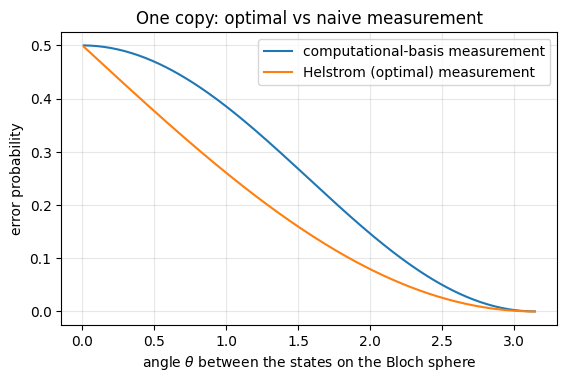

Helstrom numeric : 0.2602872306978985
Closed form      : 0.2602872306978985


In [2]:
def helstrom(rho0, rho1, p0=0.5):
    Gamma = p0*rho0 - (1-p0)*rho1
    perr = 0.5*(1 - trace_norm(Gamma))
    w, V = eigh(Gamma)
    P0 = V[:, w > 0] @ V[:, w > 0].conj().T     # projector: "guess H0"
    return perr, P0

thetas = np.linspace(0.01, np.pi, 200)
rho0 = dm(ket(0))
hel, naive = [], []
for th in thetas:
    rho1 = dm(ket(th))
    hel.append(helstrom(rho0, rho1)[0])
    # naive: Z-basis, guess H0 on outcome 0 -> only error is H1 giving outcome 0
    naive.append(0.5*np.real(rho1[0, 0]))

plt.plot(thetas, naive, label="computational-basis measurement")
plt.plot(thetas, hel, label="Helstrom (optimal) measurement")
plt.xlabel(r"angle $\theta$ between the states on the Bloch sphere")
plt.ylabel("error probability"); plt.legend(); plt.title("One copy: optimal vs naive measurement")
plt.show()

# check against the closed form for pure states: (1 - sqrt(1 - |<psi0|psi1>|^2)) / 2
th = 1.0
overlap2 = abs(ket(0).conj() @ ket(th))**2
print("Helstrom numeric :", helstrom(rho0, dm(ket(th)))[0])
print("Closed form      :", 0.5*(1 - np.sqrt(1 - overlap2)))

**What this shows:** the choice of measurement matters, and the optimal one is not the obvious one. Non-orthogonal states ($\theta<\pi$) can never be distinguished perfectly. This is the basic reason statistics over quantum systems differs from classical statistics: the data you get depends on the measurement you *choose*.

## Part 2: More copies, and measuring them together

With $n$ copies, the hypotheses become $\rho_0^{\otimes n}$ vs $\rho_1^{\otimes n}$. Two strategies:

* **Local:** measure each copy separately with the one-copy Helstrom measurement, then combine the outcomes with the best classical rule (a likelihood-ratio test).
* **Collective:** apply the Helstrom measurement to all $n$ copies *jointly*. This is the best possible strategy.

Both errors decay exponentially. For the collective strategy the rate is the **quantum Chernoff exponent**

$$\xi_Q = -\log \min_{0\le s\le 1} \operatorname{Tr}\!\left[\rho_0^{s}\rho_1^{1-s}\right], \qquad P_{\text{err}}^{*}(n) \approx e^{-n\,\xi_Q}.$$

We use slightly noisy (depolarised) states, so they are mixed rather than pure.

quantum Chernoff exponent xi_Q = 0.1152  (minimised at s = 0.50)
n=1: local 0.2962   collective 0.2962   bound 0.4456
n=2: local 0.2962   collective 0.2458   bound 0.3971
n=3: local 0.2113   collective 0.1934   bound 0.3539
n=4: local 0.2113   collective 0.1616   bound 0.3155
n=5: local 0.1581   collective 0.1340   bound 0.2811
n=6: local 0.1581   collective 0.1132   bound 0.2506
n=7: local 0.1212   collective 0.0958   bound 0.2233
n=8: local 0.1212   collective 0.0816   bound 0.1990


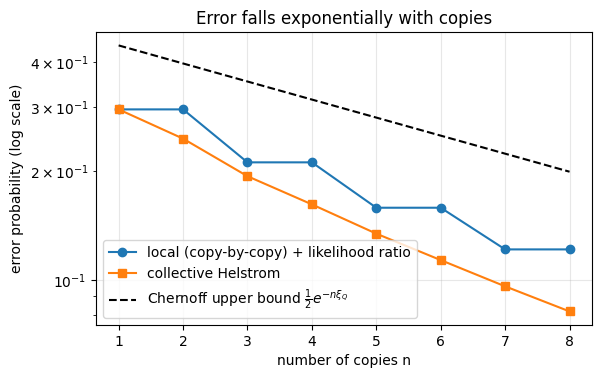

In [3]:
p_noise, th = 0.15, 1.0
r0 = depolarize(dm(ket(0)), p_noise)
r1 = depolarize(dm(ket(th)), p_noise)

ns = np.arange(1, 9)
collective = [helstrom(tensor_power(r0, n), tensor_power(r1, n))[0] for n in ns]

# local strategy: per-copy Helstrom measurement -> Bernoulli outcomes
_, P0 = helstrom(r0, r1)
q0 = np.real(np.trace(P0 @ r0))   # P(outcome "0" | H0)
q1 = np.real(np.trace(P0 @ r1))   # P(outcome "0" | H1)
def local_error(n):
    k = np.arange(n+1)                         # number of "0" outcomes
    llr = k*np.log(q0/q1) + (n-k)*np.log((1-q0)/(1-q1))
    decide0 = llr >= 0
    return 0.5*binom.pmf(k[~decide0], n, q0).sum() + 0.5*binom.pmf(k[decide0], n, q1).sum()
local = [local_error(n) for n in ns]

# quantum Chernoff exponent
ss = np.linspace(0, 1, 401)
Qs = [np.real(np.trace(mpow(r0, s) @ mpow(r1, 1-s))) for s in ss]
xi = -np.log(min(Qs))
print(f"quantum Chernoff exponent xi_Q = {xi:.4f}  (minimised at s = {ss[np.argmin(Qs)]:.2f})")

for n_, lo_, co_ in zip(ns, local, collective):
    print(f"n={n_}: local {lo_:.4f}   collective {co_:.4f}   bound {0.5*np.exp(-xi*n_):.4f}")
plt.semilogy(ns, local, "o-", label="local (copy-by-copy) + likelihood ratio")
plt.semilogy(ns, collective, "s-", label="collective Helstrom")
plt.semilogy(ns, 0.5*np.exp(-xi*ns), "k--", label=r"Chernoff upper bound $\frac{1}{2} e^{-n\xi_Q}$")
plt.xlabel("number of copies n"); plt.ylabel("error probability (log scale)")
plt.title("Error falls exponentially with copies"); plt.legend(); plt.show()

**What this shows:**
* The error falls exponentially, and the Chernoff quantity gives a valid upper bound for every $n$, not only for large $n$. Here $\tfrac12\operatorname{Tr}[\rho_0^s\rho_1^{1-s}]^n \ge P^{*}_{\text{err}}(n)$ for any $s$, a *finite-sample* guarantee.
* The local curve moves in steps: with these symmetric states, an extra copy that makes the count even can only create a tie, so it does not help.
* Measuring copies collectively can beat measuring them one at a time. This is a genuinely quantum effect, and it is part of why "how should we measure?" is itself a statistical design question.

## Part 3: Quantum relative entropy and the data-processing inequality

The quantum relative entropy

$$D(\rho\,\Vert\,\sigma) = \operatorname{Tr}\!\left[\rho(\log\rho - \log\sigma)\right]$$

is the quantum analogue of the Kullback–Leibler divergence. By **quantum Stein's lemma**, it is the best achievable exponent for the type-II error when the type-I error is held below a fixed level.

Any measurement turns the states into classical outcome distributions $P$ and $Q$. The **data-processing inequality** says no measurement can increase distinguishability: $\mathrm{KL}(P\Vert Q) \le D(\rho\Vert\sigma)$. We check this numerically over many random measurements.

D(rho0||rho1)              = 0.4908
max KL over 2000 measurements = 0.3657
data-processing inequality holds: True


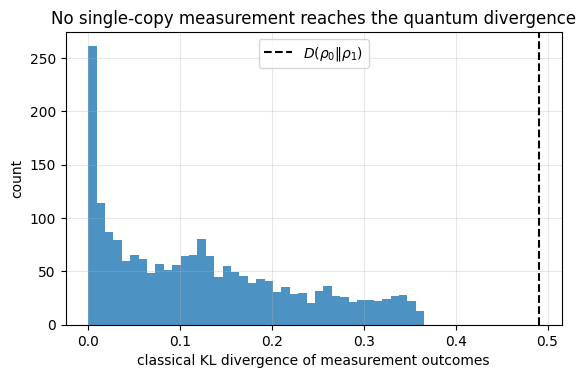

In [4]:
def qrel_entropy(rho, sigma):
    return np.real(np.trace(rho @ (mlog(rho) - mlog(sigma))))

def kl(p, q):
    p, q = np.asarray(p), np.asarray(q)
    m = p > 0
    return np.sum(p[m]*np.log(p[m]/q[m]))

D = qrel_entropy(r0, r1)
kls = []
for _ in range(2000):
    # random projective measurement = random orthonormal basis
    a, b = rng.uniform(0, np.pi), rng.uniform(0, 2*np.pi)
    e0 = ket(a, b); e1 = ket(np.pi - a, b + np.pi)  # orthogonal partner
    P = [np.real(e.conj() @ r0 @ e) for e in (e0, e1)]
    Q = [np.real(e.conj() @ r1 @ e) for e in (e0, e1)]
    kls.append(kl(P, Q))
kls = np.array(kls)
print(f"D(rho0||rho1)              = {D:.4f}")
print(f"max KL over 2000 measurements = {kls.max():.4f}")
print("data-processing inequality holds:", bool(np.all(kls <= D + 1e-12)))

plt.hist(kls, bins=40, alpha=0.8)
plt.axvline(D, color="k", ls="--", label=r"$D(\rho_0\Vert\rho_1)$")
plt.xlabel("classical KL divergence of measurement outcomes"); plt.ylabel("count")
plt.title("No single-copy measurement reaches the quantum divergence"); plt.legend(); plt.show()

**What this shows:** the quantum divergence is a ceiling. Single-copy measurements fall strictly below it, so reaching the quantum Stein exponent generally needs collective measurements across copies. How quantum divergences such as relative entropy, the Chernoff quantity and fidelity relate to each other, and how they set statistical efficiency, is one of the strands of the project.

## Part 4: Estimating a phase: quantum Fisher information and adaptive measurement

Now the task is estimation, not testing. A qubit picks up an unknown phase $\varphi$:

$$\rho_\varphi = (1-p)\,|+_\varphi\rangle\langle +_\varphi| + p\,\tfrac{I}{2}, \qquad |+_\varphi\rangle = \tfrac{1}{\sqrt2}(|0\rangle + e^{i\varphi}|1\rangle).$$

This is a toy version of **quantum sensing**, such as interferometry or magnetometry. The **quantum Cramér–Rao bound** says that any unbiased estimator using $n$ copies has

$$\operatorname{Var}(\hat\varphi) \ge \frac{1}{n\,F_Q}, $$

where $F_Q$ is the quantum Fisher information. We compute $F_Q$ with the symmetric logarithmic derivative formula, check it against the analytic value $(1-p)^2$, and then show that reaching the bound needs an **adaptive** measurement.

numerical QFI = 0.81000   analytic (1-p)^2 = 0.81000


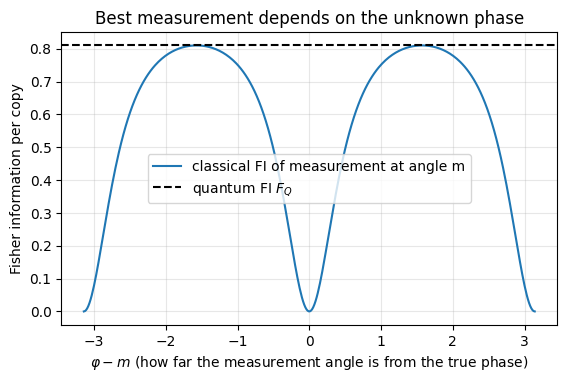

In [5]:
def rho_phase(phi, p):
    return depolarize(dm(np.array([1, np.exp(1j*phi)])/np.sqrt(2)), p)

def qfi(rho_fn, x, h=1e-5):
    # Quantum Fisher information via the SLD formula:
    # F = 2 * sum_{i,j: l_i+l_j>0} |<i|d rho|j>|^2 / (l_i + l_j)
    drho = (rho_fn(x+h) - rho_fn(x-h)) / (2*h)
    lam, V = eigh(rho_fn(x))
    M = V.conj().T @ drho @ V
    F = 0.0
    for i in range(len(lam)):
        for j in range(len(lam)):
            s = lam[i] + lam[j]
            if s > 1e-12:
                F += 2*abs(M[i, j])**2 / s
    return F

p = 0.1
print(f"numerical QFI = {qfi(lambda f: rho_phase(f, p), 0.7):.5f}   analytic (1-p)^2 = {(1-p)**2:.5f}")

# Measuring in the basis {|+_m>, |-_m>} gives P(+) = (1 + v cos(phi - m))/2, with v = 1-p.
# Classical Fisher information of that measurement:
v = 1 - p
delta = np.linspace(-np.pi, np.pi, 400)          # phi - m
Fc = v**2*np.sin(delta)**2 / (1 - v**2*np.cos(delta)**2)
plt.plot(delta, Fc, label="classical FI of measurement at angle m")
plt.axhline(v**2, color="k", ls="--", label=r"quantum FI $F_Q$")
plt.xlabel(r"$\varphi - m$ (how far the measurement angle is from the true phase)")
plt.ylabel("Fisher information per copy"); plt.legend()
plt.title("Best measurement depends on the unknown phase"); plt.show()

The plot shows the catch: the measurement that reaches $F_Q$ (angle $m=\varphi\pm\pi/2$) depends on the very parameter we want to estimate. The standard fix is **adaptive measurement**: use a few copies to get a rough estimate, then point the measurement where it is most informative.

In [6]:
def measure(phi, m, n, v):
    # n shots in basis {|+_m>,|-_m>}: number of '+' outcomes
    return rng.binomial(n, (1 + v*np.cos(phi - m))/2)

def nonadaptive(phi, n, v):
    # half the shots at m=0 (X basis), half at m=pi/2 (Y basis), combine with atan2
    kx = measure(phi, 0.0, n//2, v); ky = measure(phi, np.pi/2, n//2, v)
    return np.arctan2((2*ky/(n//2) - 1), (2*kx/(n//2) - 1))

def adaptive(phi, n, v, frac=0.1):
    n1 = int(frac*n); n2 = n - n1
    rough = nonadaptive(phi, n1, v)                   # stage 1: rough estimate
    m = rough + np.pi/2                               # stage 2: most informative angle
    k = measure(phi, m, n2, v)
    s = np.clip((2*k/n2 - 1)/v, -1, 1)                # P(+) = (1 + v sin(phi - rough))/2
    return rough + np.arcsin(s)

def wrap(x):
    return (x + np.pi) % (2*np.pi) - np.pi

n, reps = 2000, 3000
phis = rng.uniform(-np.pi, np.pi, reps)
err_na = wrap(np.array([nonadaptive(f, n, v) for f in phis]) - phis)
err_ad = wrap(np.array([adaptive(f, n, v) for f in phis]) - phis)
print(f"n x MSE, non-adaptive : {n*np.mean(err_na**2):.3f}")
print(f"n x MSE, adaptive     : {n*np.mean(err_ad**2):.3f}")
print(f"quantum CR bound 1/F_Q: {1/v**2:.3f}   (adaptive uses 90% of shots optimally -> ~{1/(0.9*v**2):.3f})")

n x MSE, non-adaptive : 2.003
n x MSE, adaptive     : 1.381
quantum CR bound 1/F_Q: 1.235   (adaptive uses 90% of shots optimally -> ~1.372)


**What this shows:** the fixed measurement pays a clear price, while the two-stage adaptive scheme comes close to the quantum Cramér–Rao limit. The remaining gap is mostly the 10% of shots spent on the rough estimate. Designing *how* to adapt, with guarantees that hold for finite $n$ rather than only asymptotically, is the "adaptive measurement" part of the project.

## Part 5: Sequential testing: stopping early while keeping type-I error control

In practice we measure one copy at a time and want to **stop as soon as the evidence is convincing**. The danger is that repeatedly checking a fixed-sample test ("peeking") inflates false alarms.

**Anytime-valid test.** Under $H_0$, the likelihood ratio $L_t = \prod_{i\le t} q_1(x_i)/q_0(x_i)$ is a non-negative martingale with mean 1, an *e-process*. **Ville's inequality** gives

$$\Pr_{H_0}\!\left(\exists\, t:\ L_t \ge 1/\alpha\right) \le \alpha,$$

so we can stop and reject the first time $L_t \ge 1/\alpha$, at *any* data-dependent time, and the type-I error stays at most $\alpha$. This holds for every sample size, not only asymptotically. Adding a lower threshold to accept $H_0$ gives Wald's sequential probability ratio test (SPRT).

We use the per-copy Helstrom measurement from Part 2, so each copy gives a Bernoulli outcome with $q_0$ under $H_0$ and $q_1$ under $H_1$.

In [7]:
alpha, beta, Tmax, R = 0.05, 0.05, 400, 4000
print(f"per-copy outcome probabilities: q0 = {q0:.3f}, q1 = {q1:.3f}")
l1 = np.log(q1/q0); l0 = np.log((1-q1)/(1-q0))   # log-LR increments for outcome 0 / 1
upper, lower = np.log(1/alpha), np.log(beta/(1-alpha))

def run_sprt(q):
    x = rng.random((R, Tmax)) < q                     # True = outcome "0"
    llr = np.cumsum(np.where(x, l1, l0), axis=1)
    hit_up = llr >= upper; hit_lo = llr <= lower
    t_up = np.where(hit_up.any(1), hit_up.argmax(1), Tmax)
    t_lo = np.where(hit_lo.any(1), hit_lo.argmax(1), Tmax)
    reject = t_up < t_lo
    stop = np.minimum(t_up, t_lo) + 1
    return reject, stop, llr

rej0, stop0, llr0 = run_sprt(q0)   # data from H0
rej1, stop1, _    = run_sprt(q1)   # data from H1
print(f"SPRT type-I error  (target <= {alpha}) : {rej0.mean():.4f}")
print(f"SPRT power                          : {rej1.mean():.4f}")
print(f"average copies used  under H0 / H1  : {stop0.mean():.1f} / {stop1.mean():.1f}")

# Pure 'stop when L_t >= 1/alpha' (no lower boundary), never stopping otherwise:
print(f"Ville test, ever rejects under H0   : {(llr0 >= upper).any(1).mean():.4f}  (guaranteed <= {alpha})")

# Fixed-n Neyman-Pearson test with the same alpha and power: smallest n
def fixed_n_needed():
    sign = 1 if q1 > q0 else -1
    for n in range(1, 2000):
        k = np.arange(n+1)
        if sign > 0:
            c = binom.ppf(1-alpha, n, q0) + 1       # reject if k >= c
            if binom.sf(c-1, n, q0) <= alpha and binom.sf(c-1, n, q1) >= 1-beta: return n
        else:
            c = binom.ppf(alpha, n, q0) - 1         # reject if k <= c
            if binom.cdf(c, n, q0) <= alpha and binom.cdf(c, n, q1) >= 1-beta: return n
print(f"fixed-sample test needs n = {fixed_n_needed()} copies for the same alpha and power")

per-copy outcome probabilities: q0 = 0.704, q1 = 0.296
SPRT type-I error  (target <= 0.05) : 0.0293
SPRT power                          : 0.9680
average copies used  under H0 / H1  : 9.2 / 9.2
Ville test, ever rejects under H0   : 0.0305  (guaranteed <= 0.05)
fixed-sample test needs n = 15 copies for the same alpha and power


'peeking' fixed-sample test, type-I error: 0.337   (nominal 0.05)


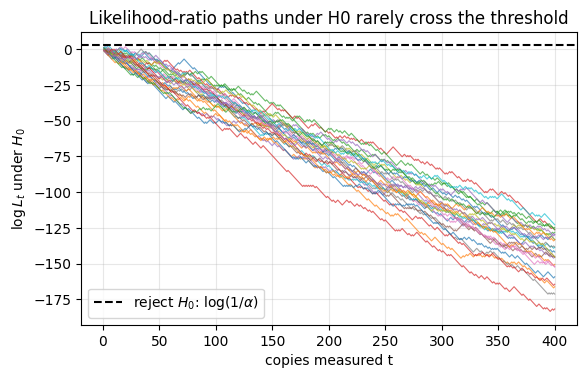

In [8]:
# The peeking problem: re-check a fixed-sample one-sided z-test after every copy under H0
z = norm.ppf(1-alpha)
x = rng.random((R, Tmax)) < q0
k = np.cumsum(x, axis=1); t = np.arange(1, Tmax+1)
zstat = (k - t*q0)/np.sqrt(t*q0*(1-q0))
zstat = zstat if q1 > q0 else -zstat
peek_reject = (zstat[:, 9:] > z).any(1).mean()        # peek from t = 10 onwards
print(f"'peeking' fixed-sample test, type-I error: {peek_reject:.3f}   (nominal {alpha})")

plt.figure()
for i in range(25):
    plt.plot(np.arange(1, Tmax+1), llr0[i], lw=0.8, alpha=0.7)
plt.axhline(upper, color="k", ls="--", label=r"reject $H_0$: $\log(1/\alpha)$")
plt.xlabel("copies measured t"); plt.ylabel(r"$\log L_t$ under $H_0$")
plt.title("Likelihood-ratio paths under H0 rarely cross the threshold"); plt.legend(); plt.show()

**What this shows:**
* The sequential test keeps type-I error below $\alpha$ even though the stopping time depends on the data, and it uses **fewer copies on average** than a fixed-sample test with the same guarantees.
* Naively re-checking a fixed-sample test after every copy inflates the false-alarm rate several-fold.
* Here the hypotheses are simple and the measurement is fixed. The project's harder questions are composite hypotheses (*universal* inference), choosing the measurement adaptively *while* testing, and keeping finite-sample guarantees throughout.

## Part 6: Check against a circuit simulator (Qiskit)

Finally, we prepare the states as real circuits, implement the Helstrom measurement from Part 1 as a basis rotation, and compare the simulated error with the formula.

In [9]:
try:
    from qiskit import QuantumCircuit
    from qiskit_aer import AerSimulator
except ImportError:
    print("Install with:  pip install qiskit qiskit-aer")
else:
    th = 1.0
    rho0p, rho1p = dm(ket(0)), dm(ket(th))
    perr_theory, P0 = helstrom(rho0p, rho1p)
    # Helstrom projector "guess H0" is rank 1: |e> = cos(a)|0> + sin(a)|1> (real here)
    w, V = eigh(0.5*rho0p - 0.5*rho1p)
    e = np.real(V[:, np.argmax(w)]); e = e*np.sign(e[0]) if e[0] != 0 else e
    a = np.arctan2(e[1], e[0])
    sim, shots, errors = AerSimulator(), 100_000, 0
    for truth, prep in [(0, 0.0), (1, th)]:
        qc = QuantumCircuit(1, 1)
        qc.ry(prep, 0)          # prepare cos(prep/2)|0> + sin(prep/2)|1>
        qc.ry(-2*a, 0)          # rotate |e> -> |0>
        qc.measure(0, 0)
        counts = sim.run(qc, shots=shots, seed_simulator=11).result().get_counts()
        guess_h0 = counts.get("0", 0)
        errors += (shots - guess_h0) if truth == 0 else guess_h0
    print(f"Helstrom error, theory   : {perr_theory:.4f}")
    print(f"Helstrom error, simulated: {errors/(2*shots):.4f}")
    print(qc.draw())

Helstrom error, theory   : 0.2603
Helstrom error, simulated: 0.2595
     ┌───────┐┌────────────┐┌─┐
  q: ┤ Ry(1) ├┤ Ry(1.0708) ├┤M├
     └───────┘└────────────┘└╥┘
c: 1/════════════════════════╩═
                             0 


## Summary and next steps

* **Measurement choice is a statistical design problem.** The optimal measurement for testing (Helstrom) or estimation (at angle $\varphi\pm\pi/2$) is not the obvious one, and for estimation it depends on the unknown parameter, which motivates adaptive schemes.
* **Quantum divergences set the limits:** trace distance for one-shot error, the Chernoff quantity for error exponents, relative entropy for Stein exponents, and Fisher information for estimation. Classical measurements of quantum states cannot exceed them (data processing).
* **Sequential, anytime-valid tests** give type-I control at every sample size and save measurements, which matters when each quantum measurement is expensive.

**Directions I would like to explore further:**
1. Sequential tests where the measurement basis is updated adaptively at each step, and how much this improves the expected stopping time.
2. Composite hypotheses (e.g. unknown noise level $p$) using universal inference or betting-based e-processes.
3. Variational quantum circuits that learn a near-optimal measurement when the Helstrom measurement is hard to implement on many qubits.

**Reading:** O. Simeone, *An Introduction to Quantum Machine Learning for Engineers*; M. Wilde, *Quantum Information Theory*; Nielsen & Chuang, *Quantum Computation and Quantum Information*; A. Ramdas et al., *Game-theoretic statistics and safe anytime-valid inference*.